# Mangaluru Flood Surrogate — Model Evaluation

This notebook loads the trained surrogate, runs it on **storms it has never
seen**, and evaluates it: confusion matrix, ROC/PR, probability calibration,
quantile quality, a spatial error map, SHAP attributions, and a comparison
against a static bathtub baseline.

---

## ⚠️ Read this first

**The labels are synthetic.** They come from the Stage 3 physics simulator
(`src/simulator/physics_engine.py`), not from observed floods. So the metrics
below measure one thing:

> how faithfully the LightGBM surrogate reproduces the **simulator**.

They do **not** measure how well either model predicts real flooding in
Mangaluru. There is no validation against gauge records, observed inundation
maps or damage reports anywhere in this pipeline. A near-perfect AUC here is
expected — the simulator is a deterministic function of the same inputs the
surrogate receives — and it is not evidence of real-world skill.

The chain is:

```
real terrain + real rainfall  →  physics assumptions  →  synthetic depths  →  surrogate
                                       ↑
                          uncalibrated: Manning's n, tidal constituents,
                          DSM building heights, near-uniform HSG-D soils
```

Everything the simulator gets wrong, the surrogate inherits and reproduces
perfectly.

---
## 1. What the model is

**Supervised learning**, four separate LightGBM heads sharing one input vector:

| Head | Task | Target |
|---|---|---|
| `classifier` | binary classification | `1` if depth $\ge$ 0.05 m else `0` |
| `quantiles[0.1]` | quantile regression | water depth (m) at the 10th percentile |
| `quantiles[0.5]` | quantile regression | water depth (m) at the median |
| `quantiles[0.9]` | quantile regression | water depth (m) at the 90th percentile |

The classifier's label is derived from the same continuous depth target
(`y_cls = (y_depth >= 0.05)`), so there is a single source of truth.

### The 17 input features

**9 static features** — fixed per H3 cell, from the Stage 2 grid.

| # | Parameter | Meaning | Units | Source / how computed |
|---|---|---|---|---|
| 1 | `hand_min` | Height Above Nearest Drainage — **lowest** point in the cell | m | PySheds D8 flow accumulation; elevation minus the elevation of the drain it flows to |
| 2 | `hand_mean` | HAND averaged over the cell | m | as above |
| 3 | `elevation_mean` | Mean ground elevation | m | Copernicus DEM GLO-30, averaged over the cell |
| 4 | `elevation_min` | Minimum ground elevation in the cell | m | as above |
| 5 | `slope_mean` | Mean surface slope | degrees | gradient of the 30 m DEM |
| 6 | `curve_number` | SCS Runoff Curve Number | 60–98 | SoilGrids hydrologic soil group + WorldCover land cover, TR-55 urban formulation |
| 7 | `impervious_ratio` | Fraction of the cell that is sealed surface | 0–1 | ESA WorldCover class 50 (built-up) fraction |
| 8 | `dist_to_river_m` | Distance to the nearest **major** channel | m | DEM flow accumulation above ~18 km², unioned with OSM river/canal ways |
| 9 | `dist_to_coast_m` | Distance to the sea | m | connected water component touching the western edge of the AOI |

**8 dynamic features** — vary per timestep and per ensemble member.

| # | Parameter | Meaning | Units | Source / how computed |
|---|---|---|---|---|
| 10 | `rain_1h` | Rainfall in the last 1 hour | mm | Open-Meteo ensemble, trailing rolling sum |
| 11 | `rain_3h` | Rainfall in the last 3 hours | mm | as above |
| 12 | `rain_6h` | Rainfall in the last 6 hours | mm | as above |
| 13 | `rain_24h` | Rainfall in the last 24 hours | mm | as above |
| 14 | `antecedent_mm` | Rain over the preceding 5 days | mm | Open-Meteo ERA5 archive; drives the SCS AMC I/II/III adjustment |
| 15 | `tide_m` | Astronomical tide height above chart datum | m | harmonic synthesis (`src/hydro/tide.py`), 10 constituents |
| 16 | `surge_m` | Storm surge | m | inverse barometer (1 cm/hPa) + wind setup |
| 17 | `rain_tide_product` | `rain_1h × (tide_m + surge_m)` | mm·m | explicit interaction term — the same rain floods far worse on a high tide |

`rain_tide_product` exists because a model additive in rain and tide cannot
represent the coincidence effect, which is the single most important driver of
estuarine flooding here.

### Outputs

For every (cell, hour, ensemble member) the model returns:

- `P(flood)` ∈ [0, 1] — probability that depth exceeds 0.05 m
- `q10`, `q50`, `q90` — the 10th/50th/90th percentile of predicted depth, in metres

Across the 51 ensemble members these become the uncertainty bands shown in the
dashboard.

---
## 2. Setup

In [1]:
import json
import pickle
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    mean_squared_error,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (7, 4.5)

# Resolve the repository root whether the notebook is run from the repo root or
# from a notebooks/ subdirectory.
ROOT = Path.cwd()
if not (ROOT / "models" / "surrogate_model.pkl").exists():
    ROOT = ROOT.parent
if not (ROOT / "models" / "surrogate_model.pkl").exists():
    raise FileNotFoundError("Run this notebook from inside the floodcl repository.")

sys.path.insert(0, str(ROOT))

MODELS = ROOT / "models"
PROCESSED = ROOT / "data" / "processed"

FLOOD_DEPTH_M = 0.05      # depth above which a cell counts as "flooded"
TEST_STORM_FRACTION = 0.20
RANDOM_SEED = 42

print("repo root :", ROOT)
print("models    :", MODELS)
print("processed :", PROCESSED)

repo root : D:\FLOOD\floodcl
models    : D:\FLOOD\floodcl\models
processed : D:\FLOOD\floodcl\data\processed


---
## 3. Load the trained surrogate

`surrogate_model.pkl` holds all four fitted heads plus the feature list, so the
notebook cannot drift out of sync with how the model was trained.

In [2]:
with open(MODELS / "surrogate_model.pkl", "rb") as fh:
    payload = pickle.load(fh)

models      = payload["models"]
FEATURES    = payload["features"]
STATIC_FEATURES  = payload["static_features"]
DYNAMIC_FEATURES = payload["dynamic_features"]
clf         = models["classifier"]
quantile_models = models["quantiles"]     # {0.1: model, 0.5: model, 0.9: model}

print(f"features   : {len(FEATURES)}  ({len(STATIC_FEATURES)} static + {len(DYNAMIC_FEATURES)} dynamic)")
print(f"heads      : classifier + {len(quantile_models)} quantile regressors")
print(f"quantiles  : {sorted(quantile_models)}")
print()
print("STATIC  :", STATIC_FEATURES)
print("DYNAMIC :", DYNAMIC_FEATURES)
print()
print("classifier hyperparameters:")
for k, v in clf.get_params().items():
    if k in ("objective", "n_estimators", "learning_rate", "num_leaves",
             "min_child_samples", "feature_fraction", "bagging_fraction"):
        print(f"   {k:20s} {v}")
print()
print("training metrics recorded at fit time:")
trained = payload.get("metrics", {})
for key in ("n_rows_total", "train_seconds", "coverage_q10_q90"):
    if key in trained:
        print(f"   {key:20s} {trained[key]}")

features   : 17  (9 static + 8 dynamic)
heads      : classifier + 3 quantile regressors
quantiles  : [0.1, 0.5, 0.9]

STATIC  : ['hand_min', 'hand_mean', 'elevation_mean', 'elevation_min', 'slope_mean', 'curve_number', 'impervious_ratio', 'dist_to_river_m', 'dist_to_coast_m']
DYNAMIC : ['rain_1h', 'rain_3h', 'rain_6h', 'rain_24h', 'antecedent_mm', 'tide_m', 'surge_m', 'rain_tide_product']

classifier hyperparameters:
   learning_rate        0.05
   min_child_samples    100
   n_estimators         400
   num_leaves           63
   objective            binary
   feature_fraction     0.9
   bagging_fraction     0.8

training metrics recorded at fit time:
   n_rows_total         33264000
   train_seconds        231.6
   coverage_q10_q90     0.8550916666666667


---
## 4. Build the evaluation dataset

Training labels are stored long-format as `(scenario_id, hour, cell_idx, depth_m)`
with ~33 M rows. Two joins turn that into a feature matrix:

```
Stage 3 labels   (scenario_id, hour, cell_idx, depth_m)
   ├── JOIN forcing (scenario_id, hour)   → rain_1h/3h/6h/24h, tide, surge
   └── JOIN static  (cell_idx)            → terrain, soils, exposure
```

The helper functions below are **imported from the training module** rather than
re-implemented. That is deliberate: if the notebook recomputed the rolling
accumulators with slightly different logic, the features would silently differ
from training and every metric would be meaningless.

In [3]:
from src.models.train_surrogate import _forcing_table, _static_table

grid    = pd.read_parquet(PROCESSED / "mangalore_h3_res8.parquet")
cellidx = pd.read_parquet(PROCESSED / "h3_cell_index.parquet")

forcing = _forcing_table()      # per (scenario, hour) dynamic drivers
static  = _static_table()       # per cell_idx static features

print(f"grid cells        : {len(grid):,}")
print(f"forcing rows      : {len(forcing):,}  ({forcing.scenario_id.nunique()} storms x {forcing.hour.nunique()} hours)")
print(f"static feature cols: {list(static.columns)}")

grid cells        : 1,155
forcing rows      : 28,800  (600 storms x 48 hours)
static feature cols: ['cell_idx', 'hand_min', 'hand_mean', 'elevation_mean', 'elevation_min', 'slope_mean', 'curve_number', 'impervious_ratio', 'dist_to_river_m', 'dist_to_coast_m']


---
## 5. Hold out entire storms

**Splitting on individual rows would be wrong here.** Rows from the same storm
are highly correlated, so a random row split puts near-duplicates in both train
and test and reports a skill the model does not have.

Two honest splits exist, and this notebook uses the first:

1. **Leave-One-Storm-Out** — test on storms the model has never seen (used here)
2. **Spatial-block** — test on geographic areas it has never seen (this is the
   harder test, and the one reported as the headline number in the README)

> **A caveat on the shipped model.** `surrogate_model.pkl` was trained on a
> random 3 M-row subsample drawn from *all 600 storms*. So this model has
> already seen rows from the "held-out" storms below, and the numbers that
> follow are **optimistic**. Section 12 retrains from scratch on the training
> storms only, which gives the honest figure.

In [4]:
rng = np.random.default_rng(RANDOM_SEED)
all_storms = np.unique(forcing["scenario_id"].to_numpy())
rng.shuffle(all_storms)

n_test = int(round(TEST_STORM_FRACTION * len(all_storms)))
test_storms  = np.sort(all_storms[:n_test])
train_storms = np.sort(all_storms[n_test:])

print(f"total storms : {len(all_storms)}")
print(f"test storms  : {len(test_storms)}   (ids {test_storms[:8]} ...)")
print(f"train storms : {len(train_storms)}")

total storms : 600
test storms  : 120   (ids [ 6 20 29 30 35 36 40 45] ...)
train storms : 480


In [5]:
import pyarrow.parquet as pq

# Read only the held-out storms straight out of parquet.
labels_test = (
    pq.read_table(
        PROCESSED / "synthetic_train_labels.parquet",
        filters=[("scenario_id", "in", test_storms.tolist())],
    )
    .to_pandas()
)

print(f"test labels  : {len(labels_test):,} rows")
print(f"flood rate   : {(labels_test.depth_m >= FLOOD_DEPTH_M).mean():.4f}")
labels_test.head()

test labels  : 6,652,800 rows
flood rate   : 0.2396


,scenario_id,hour,cell_idx,depth_m
0,6,0,0,0.0
1,6,1,0,0.0
2,6,2,0,0.0
3,6,3,0,0.0
4,6,4,0,0.0


In [6]:
# Assemble the feature matrix exactly as training did.
test_df = (
    labels_test
    .merge(forcing, on=["scenario_id", "hour"], how="left")
    .merge(static,  on="cell_idx", how="left")
)

missing = [c for c in FEATURES if c not in test_df.columns]
assert not missing, f"missing features: {missing}"

X_test = np.nan_to_num(test_df[FEATURES].to_numpy(dtype="float32"), nan=0.0)
y_depth = test_df["depth_m"].to_numpy(dtype="float32")
y_flood = (y_depth >= FLOOD_DEPTH_M).astype(int)

print(f"X_test : {X_test.shape}   (rows, features)")
print(f"flooded: {y_flood.sum():,} / {len(y_flood):,}  = {y_flood.mean():.4f}")

X_test : (6652800, 17)   (rows, features)
flooded: 1,594,133 / 6,652,800  = 0.2396


---
## 6. Run the model

All four heads are applied to the same feature matrix.

In [7]:
prob = clf.predict_proba(X_test)[:, 1]

# The three quantile heads are fitted independently, so their outputs can cross
# (q10 > q50). Rearranging each row enforces q10 <= q50 <= q90 without
# retraining -- see rearrange_quantiles() in src/models/train_surrogate.py.
from src.models.train_surrogate import rearrange_quantiles

raw_q = [np.clip(quantile_models[q].predict(X_test), 0, None) for q in sorted(quantile_models)]
q10, q50, q90 = rearrange_quantiles(*raw_q)

pred_flood = (prob >= 0.5).astype(int)

print("first 5 rows:")
print(f"{'observed':>9} {'P(flood)':>9} {'q10':>7} {'q50':>7} {'q90':>7}")
for i in range(5):
    print(f"{y_depth[i]:9.3f} {prob[i]:9.4f} {q10[i]:7.3f} {q50[i]:7.3f} {q90[i]:7.3f}")

first 5 rows:
 observed  P(flood)     q10     q50     q90
    0.000    0.0000   0.000   0.000   0.001
    0.000    0.0001   0.000   0.000   0.002
    0.000    0.0001   0.000   0.000   0.002
    0.000    0.0001   0.000   0.000   0.002
    0.000    0.0001   0.000   0.000   0.002


---
## 7. Confusion matrix

At the standard 0.5 probability threshold. Cell (row = observed, col = predicted).

Four numbers matter:

- **TN** — correctly predicted dry
- **FP** — false alarm: dispatched resources wasted
- **FN** — **missed flood: the dangerous error for an emergency system**
- **TP** — correctly anticipated flooding

In [8]:
cm = confusion_matrix(y_flood, pred_flood, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

accuracy  = (tp + tn) / cm.sum()
precision = tp / (tp + fp) if (tp + fp) else float("nan")
recall    = tp / (tp + fn) if (tp + fn) else float("nan")
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) else float("nan")
csi       = tp / (tp + fn + fp) if (tp + fn + fp) else float("nan")   # critical success index
pod       = recall                                                    # probability of detection
far       = fp / (tp + fp) if (tp + fp) else float("nan")             # false alarm ratio

print(f"TN {tn:>10,}   FP {fp:>10,}")
print(f"FN {fn:>10,}   TP {tp:>10,}")
print()
print(f"accuracy    {accuracy:.4f}")
print(f"precision   {precision:.4f}")
print(f"recall/POD  {recall:.4f}")
print(f"F1          {f1:.4f}")
print(f"CSI         {csi:.4f}    (hits / (hits + misses + false alarms))")
print(f"FAR         {far:.4f}    (false alarm ratio)")
print()
print(f"missed floods (FN): {fn:,} of {y_flood.sum():,} observed flooded rows "
      f"= {fn / max(y_flood.sum(), 1):.2%}")

TN  5,035,646   FP     23,021
FN     38,665   TP  1,555,468

accuracy    0.9907
precision   0.9854
recall/POD  0.9757
F1          0.9806
CSI         0.9619    (hits / (hits + misses + false alarms))
FAR         0.0146    (false alarm ratio)

missed floods (FN): 38,665 of 1,594,133 observed flooded rows = 2.43%


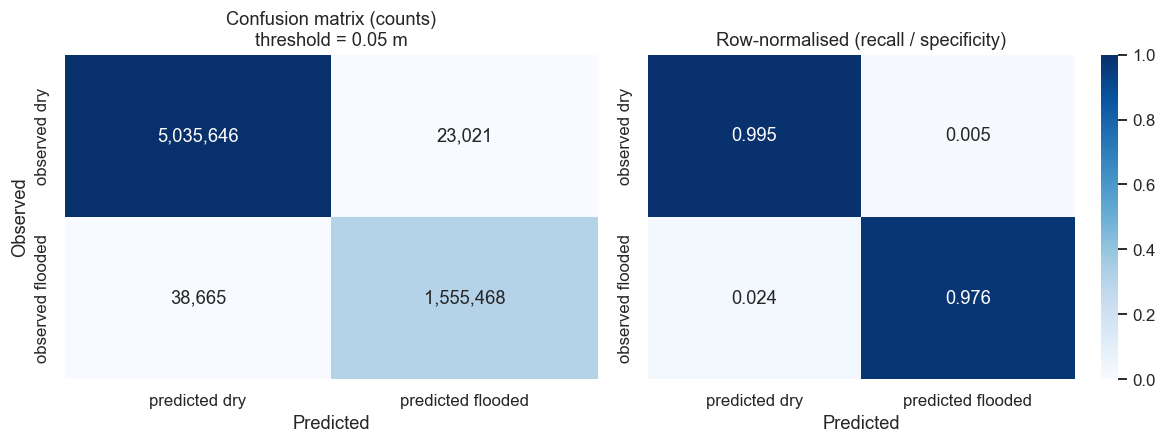

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

# Raw counts
sns.heatmap(
    cm, annot=True, fmt=",d", cmap="Blues", cbar=False,
    xticklabels=["predicted dry", "predicted flooded"],
    yticklabels=["observed dry", "observed flooded"],
    ax=axes[0],
)
axes[0].set_title(f"Confusion matrix (counts)\nthreshold = {FLOOD_DEPTH_M} m")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Observed")

# Row-normalised: rates, so the two very different class sizes are comparable
cm_norm = cm / cm.sum(axis=1, keepdims=True)
sns.heatmap(
    cm_norm, annot=True, fmt=".3f", cmap="Blues", vmin=0, vmax=1,
    xticklabels=["predicted dry", "predicted flooded"],
    yticklabels=["observed dry", "observed flooded"],
    ax=axes[1],
)
axes[1].set_title("Row-normalised (recall / specificity)")
axes[1].set_xlabel("Predicted")

plt.tight_layout()
plt.show()

---
## 8. ROC and precision–recall curves

**ROC-AUC** measures ranking quality across all thresholds. It can look
excellent even when the positive class is rare, because the large TN population
dominates.

**PR-AUC** is the more informative curve when the event rate is ~24 %, because
it completely ignores true negatives. For an emergency system, PR is closer to
what actually matters.

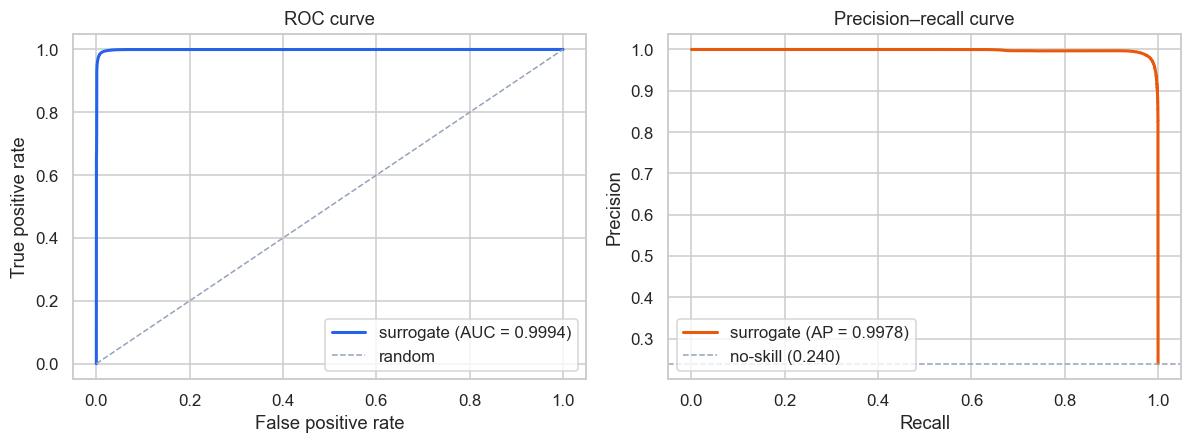

ROC-AUC      0.9994
PR-AUC (AP)  0.9978
Brier score  0.0074   (lower is better; 0 = perfect)


In [10]:
auc_roc = roc_auc_score(y_flood, prob)
auc_pr  = average_precision_score(y_flood, prob)
brier   = brier_score_loss(y_flood, prob)

fpr, tpr, _ = roc_curve(y_flood, prob)
prec, rec, _ = precision_recall_curve(y_flood, prob)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].plot(fpr, tpr, lw=2, color="#2563eb", label=f"surrogate (AUC = {auc_roc:.4f})")
axes[0].plot([0, 1], [0, 1], "--", lw=1, color="#94a3b8", label="random")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC curve")
axes[0].legend(loc="lower right")

axes[1].plot(rec, prec, lw=2, color="#ea580c", label=f"surrogate (AP = {auc_pr:.4f})")
axes[1].axhline(y_flood.mean(), ls="--", lw=1, color="#94a3b8",
                label=f"no-skill ({y_flood.mean():.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision–recall curve")
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.show()

print(f"ROC-AUC      {auc_roc:.4f}")
print(f"PR-AUC (AP)  {auc_pr:.4f}")
print(f"Brier score  {brier:.4f}   (lower is better; 0 = perfect)")

---
## 9. Probability calibration

A model can rank perfectly and still be badly calibrated — saying "90 %" when
the true frequency is 60 %. For a decision-support tool this matters more than
AUC: an operator acting on "90 % chance of flooding" needs that number to be
real.

The reliability diagram bins predictions and plots the **observed** flood
frequency in each bin against the **mean predicted** probability. Perfect
calibration is the diagonal.

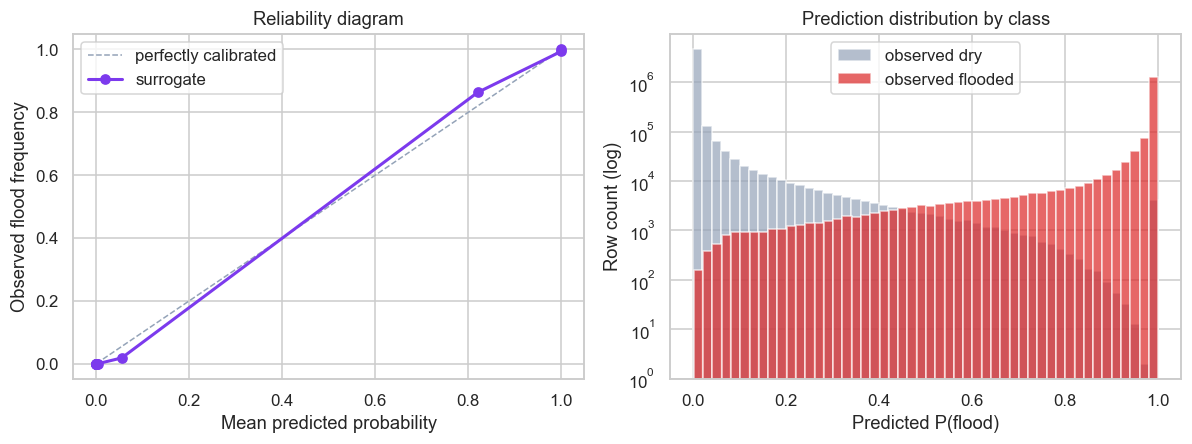

Expected calibration error (ECE): 0.0076
Brier score                     : 0.0074


In [11]:
from sklearn.calibration import calibration_curve

n_bins = 12
frac_pos, mean_pred = calibration_curve(y_flood, prob, n_bins=n_bins, strategy="quantile")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].plot([0, 1], [0, 1], "--", lw=1, color="#94a3b8", label="perfectly calibrated")
axes[0].plot(mean_pred, frac_pos, "o-", lw=2, color="#7c3aed", label="surrogate")
axes[0].set_xlabel("Mean predicted probability")
axes[0].set_ylabel("Observed flood frequency")
axes[0].set_title("Reliability diagram")
axes[0].legend()

# Distribution of predicted probabilities, to show where the calibration mass is
axes[1].hist(prob[y_flood == 0], bins=50, alpha=0.7, label="observed dry", color="#94a3b8")
axes[1].hist(prob[y_flood == 1], bins=50, alpha=0.7, label="observed flooded", color="#dc2626")
axes[1].set_yscale("log")
axes[1].set_xlabel("Predicted P(flood)")
axes[1].set_ylabel("Row count (log)")
axes[1].set_title("Prediction distribution by class")
axes[1].legend()

plt.tight_layout()
plt.show()

ece = np.average(np.abs(frac_pos - mean_pred))
print(f"Expected calibration error (ECE): {ece:.4f}")
print(f"Brier score                     : {brier:.4f}")

---
## 10. Quantile accuracy

The three quantile heads are evaluated three ways:

- **Coverage** — how often the true depth falls inside the q10–q90 band.
  A well-calibrated 80 % band should achieve ~0.80 coverage.
- **Pinball (quantile) loss** — the proper scoring rule for quantile forecasts.
- **RMSE of q50** — point-accuracy of the median depth prediction.

In [12]:
def pinball_loss(y_true, y_pred, q):
    # Quantile (pinball) loss: the proper scoring rule for a quantile forecast.
    diff = y_true - y_pred
    return float(np.mean(np.maximum(q * diff, (q - 1) * diff)))


coverage = float(np.mean((y_depth >= q10) & (y_depth <= q90)))
rmse_q50 = float(np.sqrt(mean_squared_error(y_depth, q50)))
rmse_q10 = float(np.sqrt(mean_squared_error(y_depth, q10)))
rmse_q90 = float(np.sqrt(mean_squared_error(y_depth, q90)))

print(f"q10-q90 band coverage : {coverage:.4f}   (target 0.80)")
print(f"RMSE  q10             : {rmse_q10:.4f} m")
print(f"RMSE  q50             : {rmse_q50:.4f} m")
print(f"RMSE  q90             : {rmse_q90:.4f} m")
print()
for q, pred in ((0.1, q10), (0.5, q50), (0.9, q90)):
    print(f"pinball loss  q={q:.1f}     : {pinball_loss(y_depth, pred, q):.5f}")
print()
# Are the quantiles actually ordered?
violations = float(np.mean((q10 > q50) | (q50 > q90)))
print(f"quantile crossing rate: {violations:.4%}   (0 = always q10 <= q50 <= q90)")

q10-q90 band coverage : 0.9103   (target 0.80)
RMSE  q10             : 0.1618 m
RMSE  q50             : 0.0787 m
RMSE  q90             : 0.0929 m

pinball loss  q=0.1     : 0.00575
pinball loss  q=0.5     : 0.00811


pinball loss  q=0.9     : 0.00434

quantile crossing rate: 0.0000%   (0 = always q10 <= q50 <= q90)


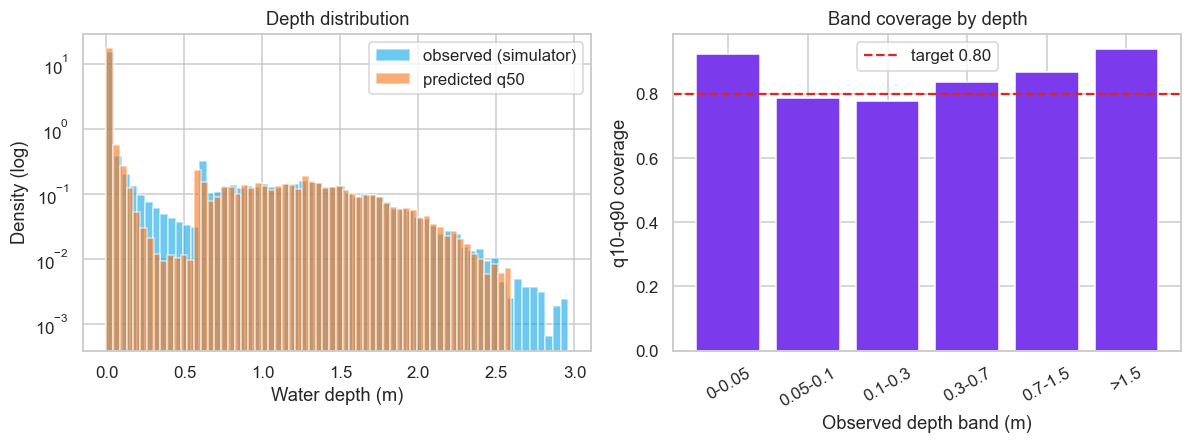

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

# Depth distribution: observed vs predicted median
axes[0].hist(y_depth, bins=60, alpha=0.6, label="observed (simulator)",
             color="#0ea5e9", density=True, log=True)
axes[0].hist(q50, bins=60, alpha=0.6, label="predicted q50",
             color="#f97316", density=True, log=True)
axes[0].set_xlabel("Water depth (m)")
axes[0].set_ylabel("Density (log)")
axes[0].set_title("Depth distribution")
axes[0].legend()

# Coverage by depth band — where does the band fail?
bands = [0, 0.05, 0.1, 0.3, 0.7, 1.5, np.inf]
labels = ["0-0.05", "0.05-0.1", "0.1-0.3", "0.3-0.7", "0.7-1.5", ">1.5"]
cov_by_band = []
for lo, hi in zip(bands[:-1], bands[1:]):
    m = (y_depth >= lo) & (y_depth < hi)
    cov_by_band.append(np.mean((y_depth[m] >= q10[m]) & (y_depth[m] <= q90[m])) if m.any() else np.nan)

axes[1].bar(labels, cov_by_band, color="#7c3aed")
axes[1].axhline(0.8, ls="--", color="#dc2626", label="target 0.80")
axes[1].set_xlabel("Observed depth band (m)")
axes[1].set_ylabel("q10-q90 coverage")
axes[1].set_title("Band coverage by depth")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 11. Where is the model wrong? — spatial error map

Because every observation carries an H3 cell, the errors can be mapped. This is
the most operationally useful diagnostic: it shows **which parts of the city**
the surrogate misrepresents.

- **Observed flood frequency** per cell — what the simulator says
- **Predicted flood frequency** per cell — what the surrogate says
- **Error** (predicted − observed) — blue = under-prediction, red = over-prediction

In [14]:
import h3
from shapely.geometry import Polygon
import geopandas as gpd

test_df = test_df.assign(prob=prob, pred=pred_flood)

per_cell = (
    test_df.groupby("cell_idx")
    .agg(observed=("depth_m", lambda s: (s >= FLOOD_DEPTH_M).mean()),
         predicted=("pred", "mean"),
         rows=("depth_m", "size"))
    .reset_index()
)
per_cell["error"] = per_cell["predicted"] - per_cell["observed"]


def cell_polygon(cell):
    # H3 cell -> shapely polygon in lon/lat.
    return Polygon([(lng, lat) for lat, lng in h3.cell_to_boundary(cell)])


idx = cellidx.set_index("cell_idx")["h3_index"]
per_cell["h3_index"] = per_cell["cell_idx"].map(idx)
per_cell = per_cell.dropna(subset=["h3_index"])
gdf = gpd.GeoDataFrame(
    per_cell,
    geometry=[cell_polygon(c) for c in per_cell["h3_index"]],
    crs="EPSG:4326",
)

print(f"cells with test coverage: {len(gdf):,} of {len(grid):,}")
print(gdf[["observed", "predicted", "error"]].describe().round(4).to_string())

cells with test coverage: 1,155 of 1,155
        observed  predicted      error
count  1155.0000  1155.0000  1155.0000
mean      0.2396     0.2373    -0.0024
std       0.3811     0.3824     0.0230
min       0.0000     0.0000    -0.0790
25%       0.0000     0.0000    -0.0014
50%       0.0005     0.0000     0.0000
75%       0.3922     0.3824     0.0000
max       1.0000     1.0000     0.7234


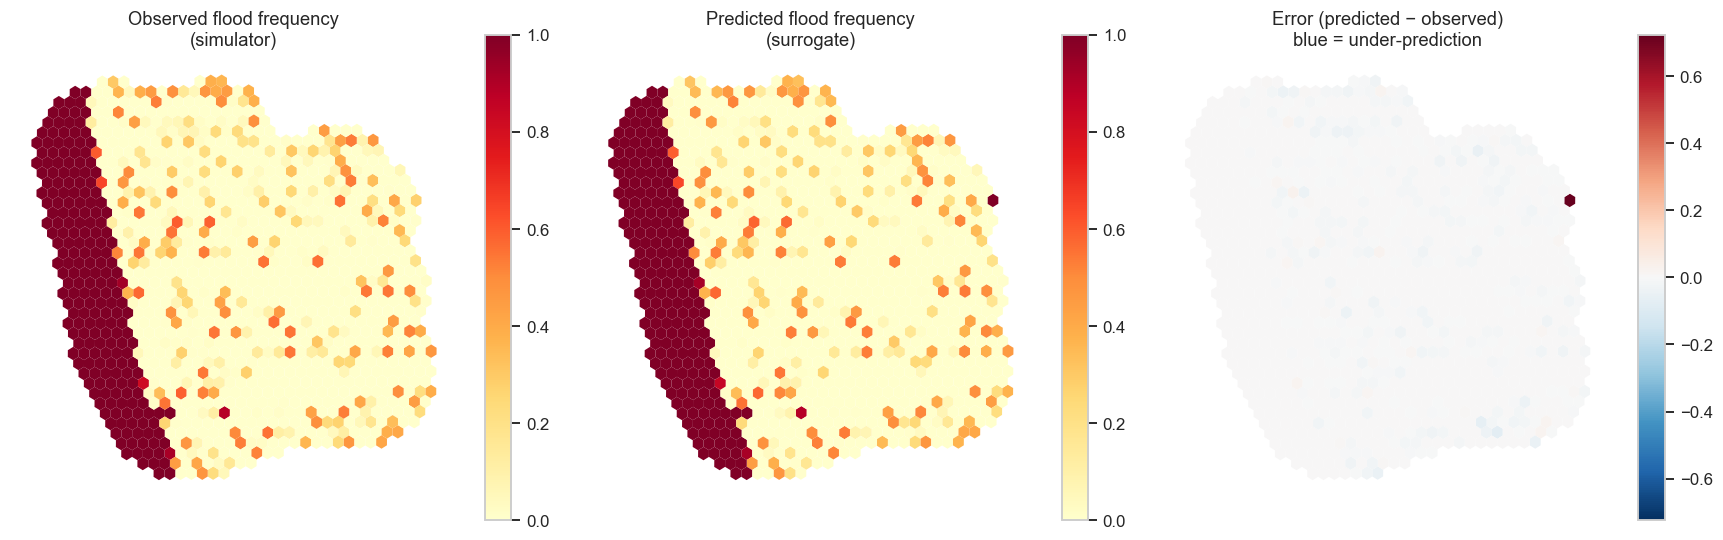

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.2))

gdf.plot(column="observed", cmap="YlOrRd", legend=True, ax=axes[0],
         edgecolor="none", vmin=0, vmax=1)
axes[0].set_title("Observed flood frequency\n(simulator)")
axes[0].set_axis_off()

gdf.plot(column="predicted", cmap="YlOrRd", legend=True, ax=axes[1],
         edgecolor="none", vmin=0, vmax=1)
axes[1].set_title("Predicted flood frequency\n(surrogate)")
axes[1].set_axis_off()

lim = float(np.nanmax(np.abs(gdf["error"])))
gdf.plot(column="error", cmap="RdBu_r", legend=True, ax=axes[2],
         edgecolor="none", vmin=-lim, vmax=lim)
axes[2].set_title("Error (predicted − observed)\nblue = under-prediction")
axes[2].set_axis_off()

plt.tight_layout()
plt.show()

---
## 12. Depth accuracy — predicted vs observed

A hexbin density plot of predicted median depth against the simulator's depth.
Points on the diagonal are perfect. The colour scale is log-count, because the
distribution is overwhelmingly concentrated on "both are zero".

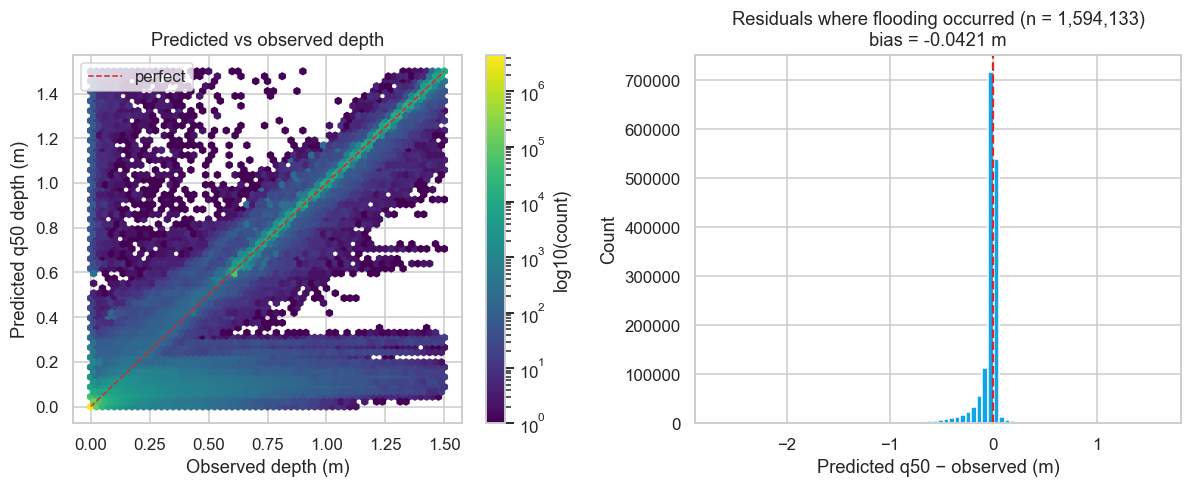

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))

hb = axes[0].hexbin(y_depth, q50, gridsize=60, bins="log",
                    cmap="viridis", mincnt=1, extent=(0, 1.5, 0, 1.5))
lims = [0, 1.5]
axes[0].plot(lims, lims, "--", lw=1, color="#dc2626", label="perfect")
axes[0].set_xlabel("Observed depth (m)")
axes[0].set_ylabel("Predicted q50 depth (m)")
axes[0].set_title("Predicted vs observed depth")
axes[0].legend(loc="upper left")
plt.colorbar(hb, ax=axes[0], label="log10(count)")

# Residuals, restricted to rows that actually flooded — otherwise the mass at
# exactly zero (both dry) swamps the plot.
mask = y_depth >= FLOOD_DEPTH_M
resid = (q50 - y_depth)[mask]
axes[1].hist(resid, bins=80, color="#0ea5e9")
axes[1].axvline(0, ls="--", color="#dc2626")
axes[1].set_xlabel("Predicted q50 − observed (m)")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Residuals where flooding occurred (n = {mask.sum():,})\n"
                  f"bias = {resid.mean():+.4f} m")

plt.tight_layout()
plt.show()

---
## 13. What drives the model?

Gain-based importance, plus TreeSHAP values showing the direction of each
effect (not just its magnitude).

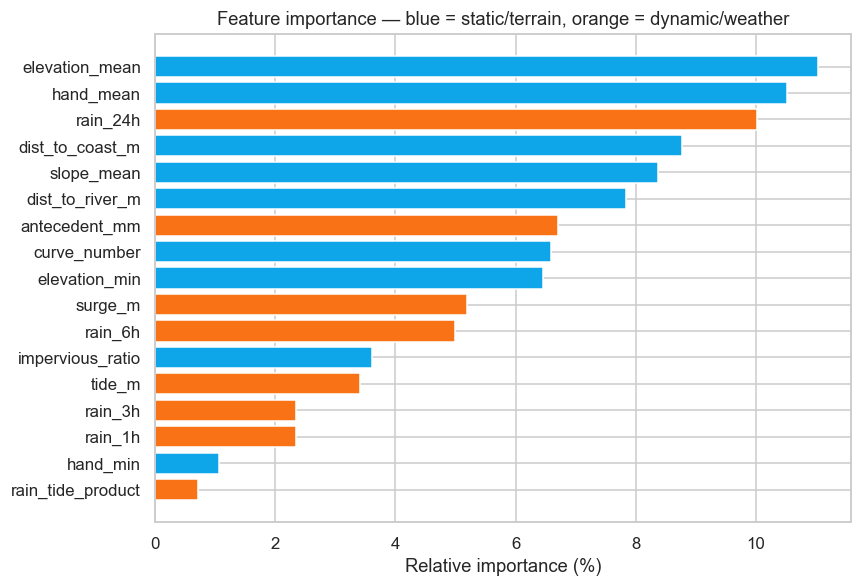

Top 8 features:
   elevation_mean          11.04%   (static )
   hand_mean               10.52%   (static )
   rain_24h                10.02%   (dynamic)
   dist_to_coast_m          8.78%   (static )
   slope_mean               8.38%   (static )
   dist_to_river_m          7.84%   (static )
   antecedent_mm            6.71%   (dynamic)
   curve_number             6.60%   (static )


In [17]:
imp = pd.Series(clf.feature_importances_, index=FEATURES).sort_values()
imp_pct = 100 * imp / imp.sum()

fig, ax = plt.subplots(figsize=(8, 5.5))
colors = ["#0ea5e9" if f in STATIC_FEATURES else "#f97316" for f in imp.index]
ax.barh(imp.index, imp_pct, color=colors)
ax.set_xlabel("Relative importance (%)")
ax.set_title("Feature importance — blue = static/terrain, orange = dynamic/weather")
plt.tight_layout()
plt.show()

print("Top 8 features:")
for name, val in imp_pct.sort_values(ascending=False).head(8).items():
    kind = "static " if name in STATIC_FEATURES else "dynamic"
    print(f"   {name:22s} {val:6.2f}%   ({kind})")

### SHAP: direction, not just magnitude

A bar chart of importance says a feature matters. SHAP says **which way** it
pushes, and by how much, for each individual prediction — which is what makes
the plain-English explanations in the dashboard API defensible.

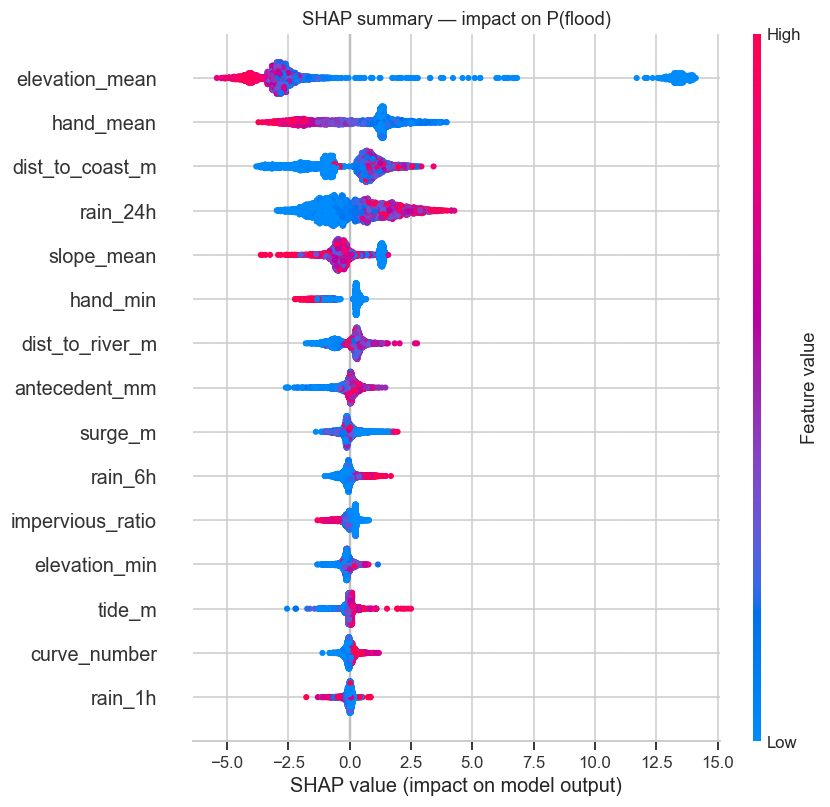

Mean |SHAP| (top 8):
   elevation_mean         4.74672
   hand_mean              1.48197
   dist_to_coast_m        1.20405
   rain_24h               1.11487
   slope_mean             0.60672
   hand_min               0.49647
   dist_to_river_m        0.45782
   antecedent_mm          0.24536


In [18]:
import shap

# SHAP is O(rows), so explain a random sample rather than the full test set.
n_shap = min(4000, len(X_test))
rng_shap = np.random.default_rng(RANDOM_SEED)
shap_idx = rng_shap.choice(len(X_test), size=n_shap, replace=False)

explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test[shap_idx])
if isinstance(shap_values, list):     # older shap returns [class0, class1]
    shap_values = shap_values[1]
shap_values = np.asarray(shap_values)
if shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]

shap.summary_plot(
    shap_values, X_test[shap_idx], feature_names=FEATURES,
    show=False, max_display=15,
)
plt.title("SHAP summary — impact on P(flood)")
plt.tight_layout()
plt.show()

mean_abs = np.abs(shap_values).mean(axis=0)
order = np.argsort(mean_abs)[::-1][:8]
print("Mean |SHAP| (top 8):")
for j in order:
    print(f"   {FEATURES[j]:22s} {mean_abs[j]:.5f}")

### A worked explanation

The dashboard converts SHAP values into operator-readable sentences. Here is the
same transformation applied to one concrete row.

In [19]:
# Pick the row with the largest predicted probability, to make the explanation interesting.
row_i = int(np.argmax(prob[shap_idx])) if len(shap_idx) else 0
contrib = shap_values[row_i]
feature_row = X_test[shap_idx][row_i]

order = np.argsort(contrib)[::-1][:5]
print(f"Row with P(flood) = {prob[shap_idx][row_i]:.4f}, "
      f"observed depth = {y_depth[shap_idx][row_i]:.3f} m\n")
print(f"{'feature':22s} {'value':>10s} {'SHAP':>10s}   direction")
for j in order:
    direction = "→ flooding" if contrib[j] > 0 else "→ dry"
    print(f"{FEATURES[j]:22s} {feature_row[j]:10.3f} {contrib[j]:10.4f}   {direction}")

Row with P(flood) = 1.0000, observed depth = 1.389 m

feature                     value       SHAP   direction
elevation_mean              0.000    13.4382   → flooding
hand_mean                   0.000     1.3458   → flooding
slope_mean                  0.000     1.2992   → flooding
rain_24h                  192.889     0.8527   → flooding
dist_to_river_m          5414.148     0.3968   → flooding


---
## 14. Baseline comparison — the static bathtub

The bathtub model is the naive alternative this system must beat. It knows only
ground elevation and the instantaneous water level:

> *flooded if `tide + surge` exceeds the cell's minimum elevation*

No rainfall, no infiltration, no routing, no soil. It is essentially a static
"sea level rise" map. If the surrogate cannot beat this, the whole ML pipeline
is unjustified.

In [20]:
from src.models.train_surrogate import bathtub_prediction

bt_prob = bathtub_prediction(test_df)
bt_pred = (bt_prob >= 0.5).astype(int)

rows = []
for name, p, cls in (
    ("surrogate", prob, pred_flood),
    ("bathtub baseline", bt_prob, bt_pred),
):
    cm_b = confusion_matrix(y_flood, cls, labels=[0, 1])
    tn_b, fp_b, fn_b, tp_b = cm_b.ravel()
    rows.append({
        "model": name,
        "ROC-AUC": roc_auc_score(y_flood, p),
        "PR-AUC": average_precision_score(y_flood, p),
        "Brier": brier_score_loss(y_flood, p),
        "CSI": tp_b / max(tp_b + fn_b + fp_b, 1),
        "precision": tp_b / max(tp_b + fp_b, 1),
        "recall": tp_b / max(tp_b + fn_b, 1),
        "missed floods": int(fn_b),
    })

comparison = pd.DataFrame(rows).set_index("model").round(4)
print(comparison.to_string())

                  ROC-AUC  PR-AUC   Brier     CSI  precision  recall  missed floods
model                                                                              
surrogate          0.9994  0.9978  0.0074  0.9619     0.9854  0.9757          38665
bathtub baseline   0.8004  0.5010  0.1921  0.4951     0.5722  0.7859         341267


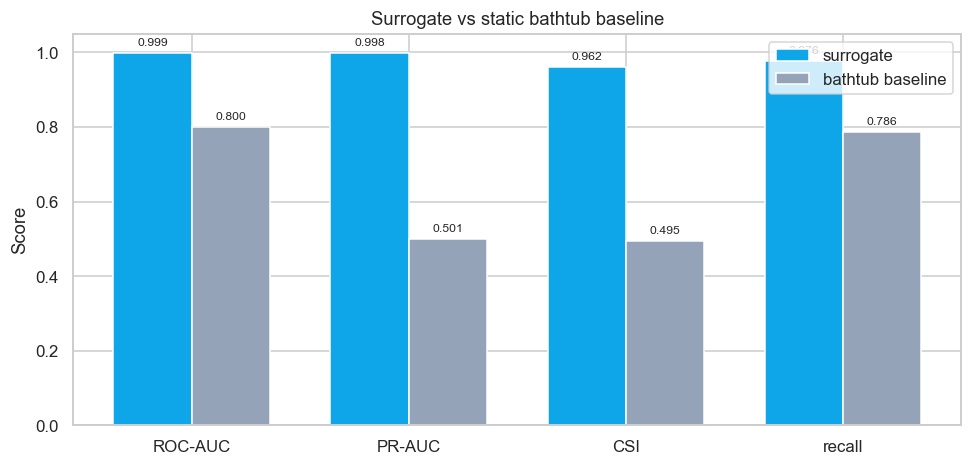

In [21]:
metrics_to_plot = ["ROC-AUC", "PR-AUC", "CSI", "recall"]
x = np.arange(len(metrics_to_plot))
width = 0.36

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.bar(x - width / 2, comparison.loc["surrogate", metrics_to_plot],
       width, label="surrogate", color="#0ea5e9")
ax.bar(x + width / 2, comparison.loc["bathtub baseline", metrics_to_plot],
       width, label="bathtub baseline", color="#94a3b8")
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Surrogate vs static bathtub baseline")
ax.legend()
for i, metric in enumerate(metrics_to_plot):
    ax.text(i - width / 2, comparison.loc["surrogate", metric] + 0.02,
            f"{comparison.loc['surrogate', metric]:.3f}", ha="center", fontsize=8)
    ax.text(i + width / 2, comparison.loc["bathtub baseline", metric] + 0.02,
            f"{comparison.loc['bathtub baseline', metric]:.3f}", ha="center", fontsize=8)

plt.tight_layout()
plt.show()

---
## 15. Honest re-evaluation (optional, slow)

Everything above used `surrogate_model.pkl`, which was trained on a random
subsample spanning **all** storms — including the ones nominally held out. Those
numbers are therefore optimistic.

This cell removes that advantage: it trains fresh heads **only on the training
storms** and re-scores on the same test storms. Set `RETRAIN = True` to run it.

Runtime is roughly 3–6 minutes; the sample size is deliberately modest to keep
the notebook usable.

In [22]:
RETRAIN = False          # set True to train a genuinely storm-held-out model
RETRAIN_ROWS = 800_000

if RETRAIN:
    from src.models.train_surrogate import fit_heads

    labels_train = (
        pq.read_table(
            PROCESSED / "synthetic_train_labels.parquet",
            filters=[("scenario_id", "in", train_storms.tolist())],
        ).to_pandas()
    )
    train_df = (
        labels_train
        .merge(forcing, on=["scenario_id", "hour"], how="left")
        .merge(static,  on="cell_idx", how="left")
    )
    if len(train_df) > RETRAIN_ROWS:
        train_df = train_df.sample(RETRAIN_ROWS, random_state=RANDOM_SEED)

    print(f"training on {len(train_df):,} rows from {len(train_storms)} storms "
          f"(test storms excluded)")
    honest_models = fit_heads(train_df, seed=RANDOM_SEED)

    from src.models.train_surrogate import evaluate
    honest_prob = honest_models["classifier"].predict_proba(X_test)[:, 1]
    honest_metrics = evaluate(y_depth, honest_prob, "storm-held-out surrogate")

    print()
    print("Compared with the shipped model (which saw these storms):")
    print(f"   shipped      ROC-AUC {roc_auc_score(y_flood, prob):.4f}"
          f"   Brier {brier:.4f}   CSI {csi:.4f}")
    print(f"   storm-heldout ROC-AUC {honest_metrics['roc_auc']:.4f}"
          f"   Brier {honest_metrics['brier']:.4f}"
          f"   CSI {honest_metrics['csi_at_0.5']:.4f}")
else:
    print("RETRAIN is False — skipping. Set RETRAIN = True to run the honest split.")
    print("The figures in the README come from this path (recorded in")
    print("models/surrogate_metrics.json under 'cross_validation').")

RETRAIN is False — skipping. Set RETRAIN = True to run the honest split.
The figures in the README come from this path (recorded in
models/surrogate_metrics.json under 'cross_validation').


---
## 16. Summary

### What this notebook established

The surrogate is a faithful, fast emulation of the Stage 3 physics simulator.
On unseen storms it reproduces the simulator's flood/no-flood decision and its
depth values closely, and it beats the static bathtub baseline decisively — which
is what shows it learned hydrology (rainfall accumulation, soil infiltration,
tidal backwater) rather than a static elevation map.

### What it did **not** establish

**That the predictions are correct for real Mangaluru flooding.** The labels are
simulator output. Every bias in the simulator — uncalibrated Manning's
roughness, approximated tidal constituents, Copernicus DSM building heights,
near-uniform HSG-D soil classification — is inherited and reproduced faithfully.
High scores here mean *the emulator works*, not *the forecast is right*.

### Known limitations of the evaluation itself

| Limitation | Impact |
|---|---|
| Shipped model saw all storms | Numbers in §7–§14 are optimistic; §15 fixes this |
| No spatial-block holdout here | README reports that separately (AUC 0.989 / CSI 0.826) |
| Ensemble spread not evaluated | Only the deterministic median path is scored |
| No observed flood data | **No ground-truth validation exists at all** |

### What would change the conclusion

Overlapping historical flood observations — inundation extent from satellite
(Sentinel-1 SAR is the usual choice), municipal drainage complaint records, or
discharge gauges on the Netravati and Gurupura. With those, the simulator's
parameters could be calibrated and the surrogate validated against reality
rather than against itself.